# Section 5: Rendering

This notebook implements various rendering techniques using PyOpenGL and numpy.

##  Setting Up the Environment

First, let's install and import the necessary libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pygame
from pygame.locals import *
from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.arrays import vbo
from OpenGL.GL import shaders
import matplotlib

# Check versions
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Pygame version: {pygame.version.ver}")

NumPy version: 1.26.4
Matplotlib version: 3.6.2
Pygame version: 2.1.2


## 5.1 Implement Basic Rendering Primitives

We'll implement and display points, lines, and triangles using PyOpenGL and Pygame.

In [3]:
def init_pygame():
    pygame.init()
    display = (800, 600)
    pygame.display.set_mode(display, DOUBLEBUF | OPENGL)
    gluPerspective(45, (display[0] / display[1]), 0.1, 50.0)
    glTranslatef(0.0, 0.0, -5)

In [4]:
def draw_points():
    # Initialize Pygame and OpenGL
    init_pygame()
    
    # Points data
    points = np.array([
        [-1.0, -1.0, 0.0],
        [1.0, -1.0, 0.0],
        [0.0, 1.0, 0.0],
        [-0.5, 0.5, 0.0],
        [0.5, 0.5, 0.0]
    ], dtype=np.float32)
    
    # Main loop
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        
        glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
        
        # Render points
        glPointSize(10)  # Set point size
        glColor3f(1.0, 0.0, 0.0)  # Red color for points
        glBegin(GL_POINTS)
        for point in points:
            glVertex3fv(point)
        glEnd()
        
        pygame.display.flip()
        pygame.time.wait(10)
    
    pygame.quit()

In [5]:
def draw_lines():
    # Initialize Pygame and OpenGL
    init_pygame()
    
    # Line data
    lines = [
        [(-1.0, -1.0, 0.0), (1.0, -1.0, 0.0)],
        [(1.0, -1.0, 0.0), (0.0, 1.0, 0.0)],
        [(0.0, 1.0, 0.0), (-1.0, -1.0, 0.0)]
    ]
    
    # Main loop
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        
        glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
        
        # Render lines
        glColor3f(0.0, 1.0, 0.0)  # Green color for lines
        glLineWidth(3)  # Set line width
        glBegin(GL_LINES)
        for line in lines:
            for point in line:
                glVertex3fv(point)
        glEnd()
        
        pygame.display.flip()
        pygame.time.wait(10)
    
    pygame.quit()

In [6]:
def draw_triangles():
    # Initialize Pygame and OpenGL
    init_pygame()
    
    # Triangle data
    triangles = [
        [(-1.0, -1.0, 0.0), (1.0, -1.0, 0.0), (0.0, 1.0, 0.0)],
    ]
    
    # Main loop
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        
        glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
        
        # Render triangles
        glColor3f(0.0, 0.0, 1.0)  # Blue color for triangles
        glBegin(GL_TRIANGLES)
        for triangle in triangles:
            for point in triangle:
                glVertex3fv(point)
        glEnd()
        
        pygame.display.flip()
        pygame.time.wait(10)
    
    pygame.quit()

In [ ]:
draw_lines()
draw_points()
draw_triangles()

You can run any of these functions to see the respective primitive rendering. For example:

```python
draw_points()
# or
draw_lines()
# or
draw_triangles()
```

## 5.2 Transformation Matrices

Here we'll implement transformation matrices for translation, rotation, and scaling and apply them to our rendering primitives.

In [7]:
def create_translation_matrix(tx, ty, tz):
    return np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ], dtype=np.float32)

In [9]:
def create_rotation_matrix_x(angle_degrees):
    angle_rad = np.radians(angle_degrees)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    return np.array([
        [1, 0, 0, 0],
        [0, cos_theta, -sin_theta, 0],
        [0, sin_theta, cos_theta, 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)

def create_rotation_matrix_y(angle_degrees):
    angle_rad = np.radians(angle_degrees)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    return np.array([
        [cos_theta, 0, sin_theta, 0],
        [0, 1, 0, 0],
        [-sin_theta, 0, cos_theta, 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)

def create_rotation_matrix_z(angle_degrees):
    angle_rad = np.radians(angle_degrees)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    return np.array([
        [cos_theta, -sin_theta, 0, 0],
        [sin_theta, cos_theta, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)

In [10]:
def create_scaling_matrix(sx, sy, sz):
    return np.array([
        [sx, 0, 0, 0],
        [0, sy, 0, 0],
        [0, 0, sz, 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)

In [11]:
def apply_transformations():
    # Initialize Pygame and OpenGL
    init_pygame()
    
    # Triangle data (homogeneous coordinates)
    triangle = np.array([
        [-0.5, -0.5, 0.0, 1.0],
        [0.5, -0.5, 0.0, 1.0],
        [0.0, 0.5, 0.0, 1.0]
    ], dtype=np.float32)
    
    # Main loop
    running = True
    angle = 0
    
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        
        glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
        
        # Create transformation matrices
        translation = create_translation_matrix(0.5 * np.sin(np.radians(angle)), 0, 0)
        rotation = create_rotation_matrix_z(angle)
        scaling = create_scaling_matrix(np.sin(np.radians(angle))*0.5 + 1, 
                                       np.sin(np.radians(angle))*0.5 + 1, 
                                       1)
        
        # Combine transformations (order matters!)
        # Scale -> Rotate -> Translate
        transform = translation @ rotation @ scaling
        
        # Apply transformation to the triangle
        transformed_triangle = np.array([transform @ vertex for vertex in triangle])
        
        # Render transformed triangle
        glColor3f(0.0, 1.0, 1.0)  # Cyan color
        glBegin(GL_TRIANGLES)
        for vertex in transformed_triangle:
            glVertex3fv(vertex[:3])  # Extract the x, y, z components
        glEnd()
        
        # Render original triangle wireframe for comparison
        glColor3f(1.0, 1.0, 1.0)  # White color
        glPolygonMode(GL_FRONT_AND_BACK, GL_LINE)
        glBegin(GL_TRIANGLES)
        for vertex in triangle:
            glVertex3fv(vertex[:3])  # Extract the x, y, z components
        glEnd()
        glPolygonMode(GL_FRONT_AND_BACK, GL_FILL)
        
        pygame.display.flip()
        pygame.time.wait(10)
        
        # Update angle for animation
        angle = (angle + 1) % 360
    
    pygame.quit()

In [25]:
apply_transformations()

You can run the transformation demo using:

```python
apply_transformations()
```

This will render a triangle that is continuously transformed (scaled, rotated, and translated).

## 5.3 Implement a Simple Rasterization Algorithm

Here we'll implement a basic software rasterizer for triangles using NumPy and Matplotlib.

In [12]:
def rasterize_triangle(v1, v2, v3, color, image):
    """
    Rasterizes a triangle defined by vertices v1, v2, v3 with the specified color on the image
    
    Args:
        v1, v2, v3: 2D points (x, y) defining the triangle vertices
        color: RGB color tuple (r, g, b) for the triangle
        image: numpy array representing the image buffer
    """
    # Convert vertices to integers (pixel coordinates)
    x1, y1 = int(v1[0]), int(v1[1])
    x2, y2 = int(v2[0]), int(v2[1])
    x3, y3 = int(v3[0]), int(v3[1])
    
    # Find bounding box of the triangle
    min_x = max(0, min(x1, x2, x3))
    max_x = min(image.shape[1]-1, max(x1, x2, x3))
    min_y = max(0, min(y1, y2, y3))
    max_y = min(image.shape[0]-1, max(y1, y2, y3))
    
    # Edge equations for barycentric coordinates
    def edge(x, y, x1, y1, x2, y2):
        return (y2 - y1) * (x - x1) - (x2 - x1) * (y - y1)
    
    # Iterate over the bounding box
    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            # Compute edge equations
            e1 = edge(x, y, x1, y1, x2, y2)
            e2 = edge(x, y, x2, y2, x3, y3)
            e3 = edge(x, y, x3, y3, x1, y1)
            
            # Check if point is inside the triangle (same side of all edges)
            # This implementation uses the edge traversal method
            if (e1 >= 0 and e2 >= 0 and e3 >= 0) or (e1 <= 0 and e2 <= 0 and e3 <= 0):
                # Set the color
                image[y, x] = color

In [13]:
def demonstrate_rasterization():
    # Create an empty image (black background)
    width, height = 400, 400
    image = np.zeros((height, width, 3))
    
    # Define triangles (in pixel coordinates)
    triangles = [
        [(100, 100), (300, 100), (200, 300)],  # Red triangle
        [(150, 150), (250, 150), (200, 50)]    # Green triangle
    ]
    
    # Colors for the triangles
    colors = [(1.0, 0.0, 0.0), (0.0, 1.0, 0.0)]
    
    # Rasterize each triangle
    for i, triangle in enumerate(triangles):
        rasterize_triangle(triangle[0], triangle[1], triangle[2], colors[i], image)
    
    # Display the result
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title("Rasterized Triangles")
    plt.axis('off')
    plt.show()
    
    # Visualize the triangle vertices
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    for i, triangle in enumerate(triangles):
        xs = [v[0] for v in triangle] + [triangle[0][0]]  # Close the loop
        ys = [v[1] for v in triangle] + [triangle[0][1]]
        plt.plot(xs, ys, '-o', color='white', linewidth=2, markersize=8)
    plt.title("Rasterized Triangles with Vertices")
    plt.axis('off')
    plt.show()

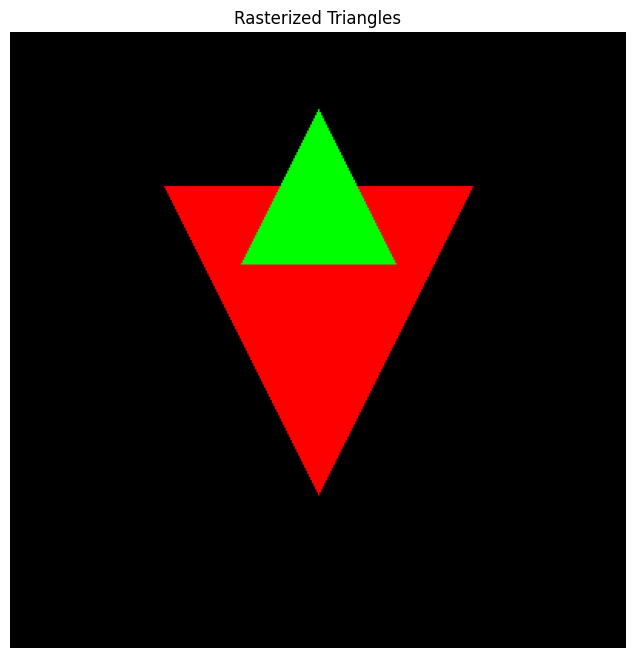

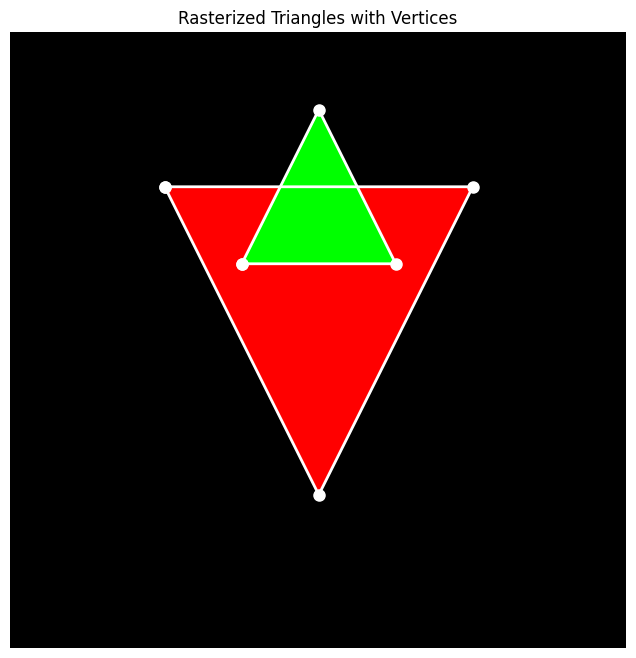

In [26]:
# Run the rasterization demonstration
demonstrate_rasterization()

### Observations on Rasterization

Our rasterization algorithm uses the edge function approach to determine which pixels lie inside the triangle. This method has several characteristics:

1. It's computationally simple, requiring only basic arithmetic operations.
2. It can have some aliasing artifacts at the edges of the triangle.
3. The algorithm is not optimized for performance - it checks every pixel in the bounding box.

More advanced rasterization techniques would include:
- Incremental calculations to avoid redundant computations
- Half-space functions for improved efficiency
- Anti-aliasing techniques to improve visual quality
- Optimizations like tile-based or hierarchical rasterization

## 5.4 Basic Shading Techniques

Let's implement two basic shading techniques: Flat shading and Gouraud shading.

In [27]:
def compute_normal(v1, v2, v3):
    """Compute the normal vector for a triangle."""
    # Convert to NumPy arrays for vector operations
    v1 = np.array(v1)
    v2 = np.array(v2)
    v3 = np.array(v3)
    
    # Calculate vectors along two edges of the triangle
    edge1 = v2 - v1
    edge2 = v3 - v1
    
    # Take the cross product to get the normal vector
    normal = np.cross(edge1, edge2)
    
    # Normalize the normal vector
    magnitude = np.linalg.norm(normal)
    if magnitude > 0:
        normal = normal / magnitude
    
    return normal

In [16]:
def flat_shade_triangle(v1, v2, v3, base_color, light_dir, image):
    """Rasterize a triangle with flat shading."""
    # Compute the normal for the entire triangle
    normal = compute_normal(v1, v2, v3)
    
    # Normalize the light direction vector
    light_dir = light_dir / np.linalg.norm(light_dir)
    
    # Calculate diffuse lighting intensity using dot product between normal and light direction
    # Clamp to prevent negative values
    intensity = max(0.1, np.dot(normal, light_dir))  # 0.1 is ambient light
    
    # Apply lighting to color
    color = tuple(c * intensity for c in base_color)
    
    # Rasterize the triangle with the flat shaded color
    rasterize_triangle(v1[:2], v2[:2], v3[:2], color, image)

In [28]:
def compute_vertex_normal(vertex, vertices, faces):
    """Compute the vertex normal by averaging face normals of adjacent triangles."""
    normals = []
    
    # Find all triangles that include this vertex
    for face in faces:
        if vertex in face:
            # Get the vertices of this face
            v1 = vertices[face[0]]
            v2 = vertices[face[1]]
            v3 = vertices[face[2]]
            
            # Compute face normal
            normal = compute_normal(v1, v2, v3)
            normals.append(normal)
    
    # Average the normals
    avg_normal = np.mean(normals, axis=0)
    
    # Normalize
    magnitude = np.linalg.norm(avg_normal)
    if magnitude > 0:
        avg_normal = avg_normal / magnitude
    
    return avg_normal

In [29]:
def interpolate_color(x, y, v1, v2, v3, c1, c2, c3):
    """Interpolate color using barycentric coordinates."""
    # Extract 2D coordinates
    x1, y1 = v1[:2]
    x2, y2 = v2[:2]
    x3, y3 = v3[:2]
    
    # Compute the area of the full triangle
    area = abs((x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2)) / 2.0)
    
    # Compute barycentric coordinates
    alpha = abs((x*(y2-y3) + x2*(y3-y) + x3*(y-y2)) / (2.0 * area))
    beta = abs((x1*(y-y3) + x*(y3-y1) + x3*(y1-y)) / (2.0 * area))
    gamma = 1.0 - alpha - beta
    
    # Interpolate color
    r = alpha * c1[0] + beta * c2[0] + gamma * c3[0]
    g = alpha * c1[1] + beta * c2[1] + gamma * c3[1]
    b = alpha * c1[2] + beta * c2[2] + gamma * c3[2]
    
    return (r, g, b)

In [30]:
def gouraud_shade_triangle(v1, v2, v3, n1, n2, n3, base_color, light_dir, image):
    """Rasterize a triangle with Gouraud shading (per-vertex lighting)."""
    # Normalize the light direction
    light_dir = light_dir / np.linalg.norm(light_dir)
    
    # Calculate lighting at each vertex
    i1 = max(0.1, np.dot(n1, light_dir))  # Vertex 1 intensity
    i2 = max(0.1, np.dot(n2, light_dir))  # Vertex 2 intensity
    i3 = max(0.1, np.dot(n3, light_dir))  # Vertex 3 intensity
    
    # Vertex colors with lighting applied
    c1 = tuple(c * i1 for c in base_color)
    c2 = tuple(c * i2 for c in base_color)
    c3 = tuple(c * i3 for c in base_color)
    
    # Convert vertices to integers
    x1, y1 = int(v1[0]), int(v1[1])
    x2, y2 = int(v2[0]), int(v2[1])
    x3, y3 = int(v3[0]), int(v3[1])
    
    # Find bounding box
    min_x = max(0, min(x1, x2, x3))
    max_x = min(image.shape[1]-1, max(x1, x2, x3))
    min_y = max(0, min(y1, y2, y3))
    max_y = min(image.shape[0]-1, max(y1, y2, y3))
    
    # Edge function
    def edge(x, y, x1, y1, x2, y2):
        return (y2 - y1) * (x - x1) - (x2 - x1) * (y - y1)
    
    # Rasterize with color interpolation
    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            e1 = edge(x, y, x1, y1, x2, y2)
            e2 = edge(x, y, x2, y2, x3, y3)
            e3 = edge(x, y, x3, y3, x1, y1)
            
            # If point is inside the triangle
            if (e1 >= 0 and e2 >= 0 and e3 >= 0) or (e1 <= 0 and e2 <= 0 and e3 <= 0):
                # Interpolate color based on barycentric coordinates
                color = interpolate_color(x, y, v1, v2, v3, c1, c2, c3)
                image[y, x] = color

In [31]:
def demonstrate_shading():
    # Create image for flat shading
    width, height = 400, 400
    flat_image = np.zeros((height, width, 3))
    gouraud_image = np.zeros((height, width, 3))
    
    # Define a cube mesh (vertices and faces)
    vertices = [
        np.array([100, 100, 0]),   # 0: front bottom left
        np.array([300, 100, 0]),   # 1: front bottom right
        np.array([300, 300, 0]),   # 2: front top right
        np.array([100, 300, 0]),   # 3: front top left
        np.array([150, 150, 100]), # 4: back bottom left
        np.array([250, 150, 100]), # 5: back bottom right
        np.array([250, 250, 100]), # 6: back top right
        np.array([150, 250, 100])  # 7: back top left
    ]
    
    # Faces (triangles)
    faces = [
        [0, 1, 2], [0, 2, 3],  # Front face
        [4, 5, 6], [4, 6, 7],  # Back face
        [0, 4, 7], [0, 7, 3],  # Left face
        [1, 5, 6], [1, 6, 2],  # Right face
        [3, 2, 6], [3, 6, 7],  # Top face
        [0, 1, 5], [0, 5, 4]   # Bottom face
    ]
    
    # Base colors for the faces
    colors = [
        (1.0, 0.0, 0.0),  # Red
        (0.0, 1.0, 0.0),  # Green
        (0.0, 0.0, 1.0),  # Blue
        (1.0, 1.0, 0.0),  # Yellow
        (1.0, 0.0, 1.0),  # Magenta
        (0.0, 1.0, 1.0)   # Cyan
    ]
    
    # Light direction
    light_dir = np.array([0.5, 0.5, 1.0])
    
    # Compute vertex normals for Gouraud shading
    vertex_normals = [compute_vertex_normal(i, vertices, faces) for i in range(len(vertices))]
    
    # Apply flat shading
    for i, face in enumerate(faces):
        v1, v2, v3 = vertices[face[0]], vertices[face[1]], vertices[face[2]]
        # Use face color based on which cube face it belongs to
        color_idx = i // 2
        flat_shade_triangle(v1, v2, v3, colors[color_idx % len(colors)], light_dir, flat_image)
    
    # Apply Gouraud shading
    for i, face in enumerate(faces):
        idx1, idx2, idx3 = face[0], face[1], face[2]
        v1, v2, v3 = vertices[idx1], vertices[idx2], vertices[idx3]
        n1, n2, n3 = vertex_normals[idx1], vertex_normals[idx2], vertex_normals[idx3]
        color_idx = i // 2
        gouraud_shade_triangle(v1, v2, v3, n1, n2, n3, colors[color_idx % len(colors)], light_dir, gouraud_image)
    
    # Display the results
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(flat_image)
    axes[0].set_title("Flat Shading")
    axes[0].axis('off')
    
    axes[1].imshow(gouraud_image)
    axes[1].set_title("Gouraud Shading")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

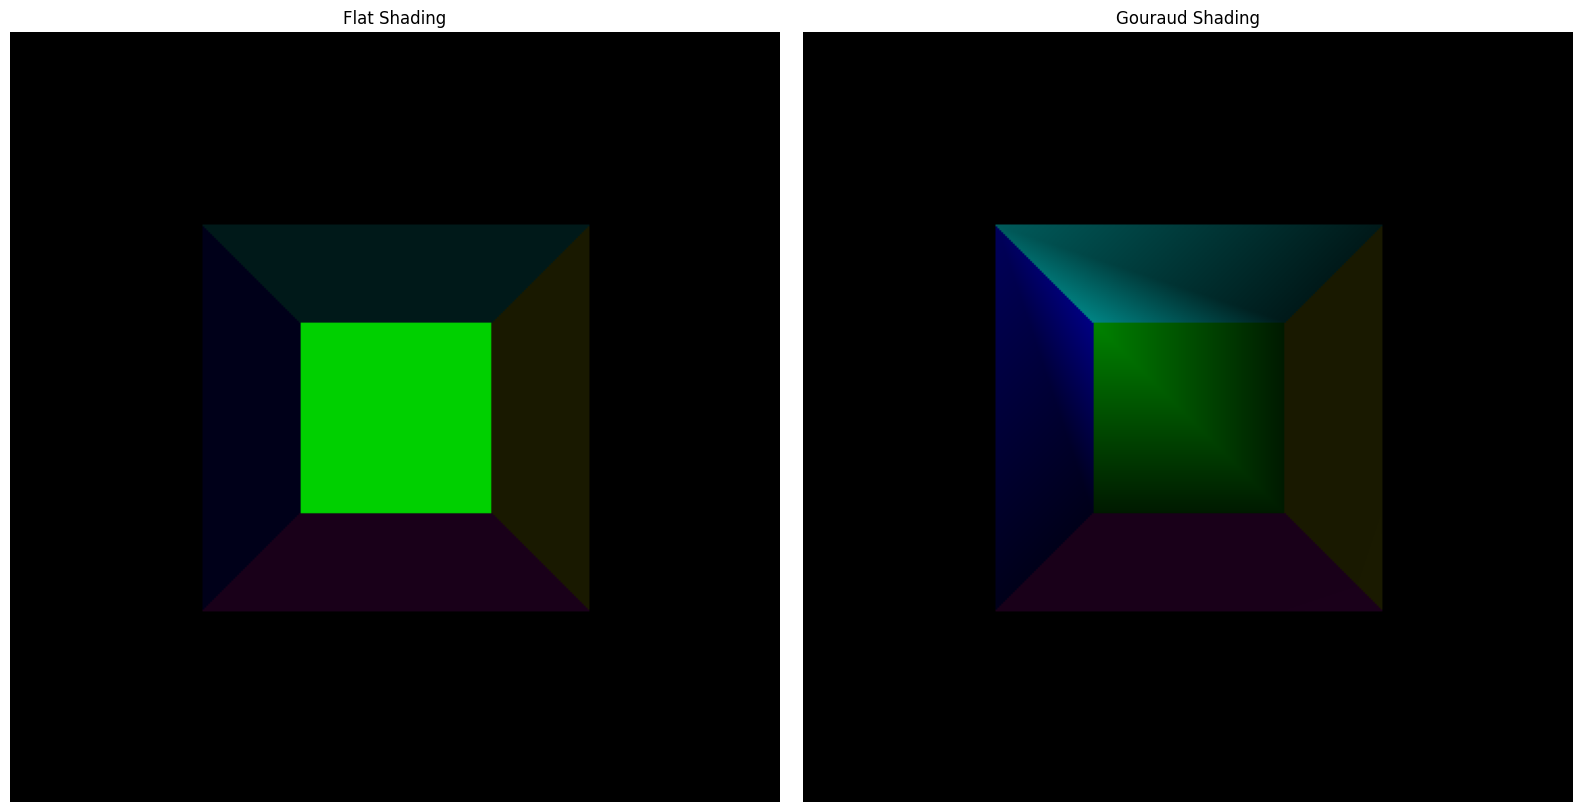

In [32]:
# Run the shading demonstration
demonstrate_shading()

### Observations on Shading Techniques

#### Flat Shading
- Uses a single normal vector per face
- Lighting calculation happens once per triangle
- Creates a faceted appearance where the boundaries between triangles are visible
- More efficient but less realistic
- Works well for low-poly stylized models

#### Gouraud Shading
- Computes lighting at vertices using vertex normals (averaged from surrounding faces)
- Interpolates lighting values across the triangle surface
- Creates smoother appearance with less visible triangle boundaries
- More computationally expensive than flat shading
- May still show artifacts at specular highlights (which would be better handled by Phong shading)

The main visual difference is that Gouraud shading creates smoother color gradients across surfaces, while flat shading results in a more "faceted" appearance with visible edges between triangles.

## Summary

In this notebook, we have implemented and explored various rendering techniques:

1. **Basic Rendering Primitives**: We implemented points, lines, and triangles using PyOpenGL.

2. **Transformation Matrices**: We created and applied translation, rotation, and scaling transformations to our rendering primitives.

3. **Rasterization**: We implemented a simple software rasterizer to render triangles pixel by pixel.

4. **Shading Techniques**: We implemented two basic shading algorithms - flat shading and Gouraud shading.

Through these implementations, we've been able to understand the fundamental concepts behind computer graphics rendering. We've seen how primitive shapes are defined, transformed, and ultimately rendered onto a 2D screen, and explored how different shading techniques can improve visual quality.